In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/Dekhsa/Big-Data/refs/heads/main/practical-session/final-project/datasets/steamdb_top_sellers_2019-2024.csv')
df

,Tahun Rilis,Rank,Nama Game,Diskon,Harga,Rating,Tanggal Rilis,Followers,Online Saat Ini,Peak Pemain
0,2019,46.0,Destiny 2,0%,Free,79.01%,01 Oct,"719,675","23,683","316,750"
1,2019,50.0,Hunt: Showdown 1896,-50%,Rp 127500,72.01%,27 Aug,"487,821","11,991","60,124"
2,2019,78.0,STAR WARS Jedi: Fallen Order™,-75%,Rp 119750,87.54%,15 Nov,"205,752","2,262","46,550"
3,2019,81.0,Blasphemous,-90%,Rp 19999,88.56%,10 Sep,"90,902","2,274","3,465"
4,2019,121.0,Oxygen Not Included,-70%,Rp 35999,95.39%,30 Jul,"396,429","10,600","27,486"
...,...,...,...,...,...,...,...,...,...,...
595,2024,513.0,Buckshot Roulette,0%,Rp 28999,94.55%,04 Apr,"66,069",842,"20,226"
596,2024,519.0,Crusader Kings III: Roads to Power,0%,Rp 321999,80.49%,24 Sep,—,—,—
597,2024,532.0,Void Crew,0%,Rp 219000,85.42%,25 Nov,"56,198",692,"4,722"
598,2024,540.0,Abiotic Factor,0%,Rp 284999,94.38%,02 May,"99,658","1,494","21,753"


**DATA PREPROCESSING**


In [4]:
# Cek struktur kolom dan tipe data
df.info()

# Cek jumlah missing value tiap kolom
print("\nMissing Values:")
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Tahun Rilis      600 non-null    int64  
 1   Rank             600 non-null    float64
 2   Nama Game        600 non-null    object 
 3   Diskon           600 non-null    object 
 4   Harga            600 non-null    object 
 5   Rating           600 non-null    object 
 6   Tanggal Rilis    600 non-null    object 
 7   Followers        600 non-null    object 
 8   Online Saat Ini  600 non-null    object 
 9   Peak Pemain      600 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 47.0+ KB

Missing Values:
Tahun Rilis        0
Rank               0
Nama Game          0
Diskon             0
Harga              0
Rating             0
Tanggal Rilis      0
Followers          0
Online Saat Ini    0
Peak Pemain        0
dtype: int64


In [5]:
# Lihat beberapa sampel data
df.sample(5)

# Lihat nilai unik pada kolom penting
print("Unique values for 'Diskon':", df['Diskon'].unique())
print("Unique values for 'Rating':", df['Rating'].unique())

Unique values for 'Diskon': ['0%' '-50%' '-75%' '-90%' '-70%' '-80%' '-85%' '-60%' '-62%' '-40%'
 '-30%' '-66%' '-67%' '-77%' '-43%' '-88%' '-55%' '-95%' '-71%' '-45%'
 '-33%' '-27%' '-65%' '-35%' '-34%' '-86%' '-20%' '-52%' '-25%' '-15%'
 '-10%' '-59%' '-38%' '-22%' '-47%']
Unique values for 'Rating': ['79.01%' '72.01%' '87.54%' '88.56%' '95.39%' '90.78%' '91.05%' '90.41%'
 '86.94%' '71.57%' '93.62%' '82.94%' '84.54%' '—' '84.75%' '89.76%'
 '88.64%' '94.27%' '73.29%' '91.36%' '63.39%' '85.69%' '92.28%' '79.68%'
 '94.04%' '94.28%' '96.37%' '87.46%' '86.79%' '96.54%' '92.88%' '42.17%'
 '53.41%' '70.83%' '88.49%' '91.87%' '80.37%' '80.41%' '67.07%' '63.71%'
 '94.92%' '88.73%' '50.29%' '80.63%' '97.46%' '65.70%' '88.53%' '59.80%'
 '92.49%' '86.12%' '95.75%' '93.60%' '91.78%' '88.51%' '91.35%' '86.84%'
 '81.25%' '93.11%' '93.34%' '86.85%' '84.52%' '84.96%' '67.64%' '81.05%'
 '93.26%' '69.37%' '65.92%' '72.24%' '77.66%' '78.64%' '88.84%' '94.72%'
 '66.83%' '65.11%' '71.46%' '83.29%' '69.93%

In [6]:
# --- Rename kolom ke bahasa Inggris ---
df = df.rename(columns={
    'Tahun Rilis': 'Release Year',
    'Nama Game': 'Game Name',
    'Diskon': 'Discount',
    'Harga': 'Price',
    'Rating': 'Rating',
    'Tanggal Rilis': 'Release Date',
    'Followers': 'Followers',
    'Online Saat Ini': 'Online Now',
    'Peak Pemain': 'Peak Players',
    'Rank': 'Rank'
})

# --- Fungsi parsing diskon ---
def parse_discount(value):
    try:
        if pd.isna(value): return 0
        value_str = str(value).lower().strip()
        if value_str in ["", "free", "gratis", "—", "nan", "none"]:
            return 0
        digits = ''.join(ch for ch in value_str if ch.isdigit())
        return int(digits) if digits else 0
    except:
        return 0

# --- Fungsi parsing rating ---
def parse_rating(value):
    try:
        if pd.isna(value): return 0
        value_str = str(value).lower().strip()
        if value_str in ["", "—", "nan", "none"]:
            return 0
        digits = ''.join(ch for ch in value_str if ch.isdigit() or ch == '.')
        return int(float(digits)) if digits else 0
    except:
        return 0

# --- Fungsi parsing integer umum ---
def parse_int(value):
    try:
        if pd.isna(value): return 0
        value_str = str(value).lower().strip()
        digits = ''.join(ch for ch in value_str if ch.isdigit())
        return int(digits) if digits else 0
    except:
        return 0

# --- Preprocessing semua kolom numerik ---
df['Discount'] = df['Discount'].apply(parse_discount)
df['Rating'] = df['Rating'].apply(parse_rating)
df['Price'] = df['Price'].apply(parse_int)
df['Online Now'] = df['Online Now'].apply(parse_int)
df['Peak Players'] = df['Peak Players'].apply(parse_int)
df['Rank'] = df['Rank'].apply(parse_int)
df['Followers'] = df['Followers'].apply(parse_int)

# --- Gabungkan Release Date dan Release Year ke satu datetime ---
df['Release Merge'] = df['Release Date'].astype(str).str.strip() + ' ' + df['Release Year'].astype(str)
df['Release Date'] = pd.to_datetime(df['Release Merge'], format='%d %b %Y', errors='coerce')
df['Release Date'] = df['Release Date'].dt.strftime('%m/%d/%Y')

# --- Buat DataFrame final yang bersih ---
df_clean = df[['Game Name', 'Rank', 'Price', 'Rating', 'Discount', 'Followers',
               'Online Now', 'Peak Players']].copy()

# Tambahkan kolom status harga dan diskon
df_clean['Price Status'] = df_clean['Price'].apply(lambda x: 1 if x > 0 else 0)
df_clean['Discount Status'] = df_clean['Discount'].apply(lambda x: 1 if x > 0 else 0)

# Tambahkan kolom tanggal rilis final
df_clean['Release Date'] = df['Release Date']

# --- Tampilkan semua kolom & semua baris ---
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# --- Output hasil bersih ---
display(df_clean)

,Game Name,Rank,Price,Rating,Discount,Followers,Online Now,Peak Players,Price Status,Discount Status,Release Date
0,Destiny 2,460,0,79,0,719675,23683,316750,0,0,10/01/2019
1,Hunt: Showdown 1896,500,127500,72,50,487821,11991,60124,1,1,08/27/2019
2,STAR WARS Jedi: Fallen Order™,780,119750,87,75,205752,2262,46550,1,1,11/15/2019
3,Blasphemous,810,19999,88,90,90902,2274,3465,1,1,09/10/2019
4,Oxygen Not Included,1210,35999,95,70,396429,10600,27486,1,1,07/30/2019
5,Assetto Corsa Competizione,1310,112250,90,75,139112,1038,12376,1,1,05/29/2019
6,Red Dead Redemption 2,1330,879000,91,0,875506,23939,99993,1,0,12/05/2019
7,Trailmakers,1480,29999,90,75,72105,1472,4898,1,1,09/18/2019
8,Mortal Kombat 11,1560,0,86,0,168432,1467,35147,0,0,04/23/2019
9,Total War: THREE KINGDOMS,1850,135249,71,75,499140,3781,192298,1,1,05/23/2019


In [7]:
# Tampilkan semua kolom (opsional karena default-nya semua kolom sudah terlihat)
pd.set_option('display.max_columns', None)

# Tampilkan semua baris
pd.set_option('display.max_rows', None)

# Tampilkan dataframe bersih lengkap
display(df_clean)


,Game Name,Rank,Price,Rating,Discount,Followers,Online Now,Peak Players,Price Status,Discount Status,Release Date
0,Destiny 2,460,0,79,0,719675,23683,316750,0,0,10/01/2019
1,Hunt: Showdown 1896,500,127500,72,50,487821,11991,60124,1,1,08/27/2019
2,STAR WARS Jedi: Fallen Order™,780,119750,87,75,205752,2262,46550,1,1,11/15/2019
3,Blasphemous,810,19999,88,90,90902,2274,3465,1,1,09/10/2019
4,Oxygen Not Included,1210,35999,95,70,396429,10600,27486,1,1,07/30/2019
5,Assetto Corsa Competizione,1310,112250,90,75,139112,1038,12376,1,1,05/29/2019
6,Red Dead Redemption 2,1330,879000,91,0,875506,23939,99993,1,0,12/05/2019
7,Trailmakers,1480,29999,90,75,72105,1472,4898,1,1,09/18/2019
8,Mortal Kombat 11,1560,0,86,0,168432,1467,35147,0,0,04/23/2019
9,Total War: THREE KINGDOMS,1850,135249,71,75,499140,3781,192298,1,1,05/23/2019


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Release Year   600 non-null    int64 
 1   Rank           600 non-null    int64 
 2   Game Name      600 non-null    object
 3   Discount       600 non-null    int64 
 4   Price          600 non-null    int64 
 5   Rating         600 non-null    int64 
 6   Release Date   600 non-null    object
 7   Followers      600 non-null    int64 
 8   Online Now     600 non-null    int64 
 9   Peak Players   600 non-null    int64 
 10  Release Merge  600 non-null    object
dtypes: int64(8), object(3)
memory usage: 51.7+ KB


In [9]:
df.describe()

,Release Year,Rank,Discount,Price,Rating,Followers,Online Now,Peak Players
count,600.00000,600.000000,600.000000,6.000000e+02,600.000000,6.000000e+02,600.000000,6.000000e+02
mean,2021.50000,6796.183333,24.131667,2.086406e+05,78.720000,1.149330e+05,2856.078333,5.051353e+04
std,1.70925,4688.995813,30.290706,2.163450e+05,15.768196,1.950086e+05,7842.718035,1.764756e+05
min,2019.00000,90.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
25%,2020.00000,3047.500000,0.000000,6.002150e+04,72.000000,1.814525e+04,84.000000,1.336000e+03
50%,2021.50000,5620.000000,0.000000,1.429995e+05,83.000000,6.004150e+04,478.500000,8.128500e+03
75%,2023.00000,10095.000000,50.000000,2.849990e+05,89.000000,1.312035e+05,1953.750000,2.848300e+04
max,2024.00000,19730.000000,95.000000,1.656012e+06,97.000000,2.712239e+06,94064.000000,2.415714e+06


#EXPLORATORY DATA ANALYSIS


In [10]:
print("10 Baris Pertama:")
display(df.head())

print("\n9 Baris Terakhir:")
display(df.tail())

10 Baris Pertama:


,Release Year,Rank,Game Name,Discount,Price,Rating,Release Date,Followers,Online Now,Peak Players,Release Merge
0,2019,460,Destiny 2,0,0,79,10/01/2019,719675,23683,316750,01 Oct 2019
1,2019,500,Hunt: Showdown 1896,50,127500,72,08/27/2019,487821,11991,60124,27 Aug 2019
2,2019,780,STAR WARS Jedi: Fallen Order™,75,119750,87,11/15/2019,205752,2262,46550,15 Nov 2019
3,2019,810,Blasphemous,90,19999,88,09/10/2019,90902,2274,3465,10 Sep 2019
4,2019,1210,Oxygen Not Included,70,35999,95,07/30/2019,396429,10600,27486,30 Jul 2019



9 Baris Terakhir:


,Release Year,Rank,Game Name,Discount,Price,Rating,Release Date,Followers,Online Now,Peak Players,Release Merge
595,2024,5130,Buckshot Roulette,0,28999,94,04/04/2024,66069,842,20226,04 Apr 2024
596,2024,5190,Crusader Kings III: Roads to Power,0,321999,80,09/24/2024,0,0,0,24 Sep 2024
597,2024,5320,Void Crew,0,219000,85,11/25/2024,56198,692,4722,25 Nov 2024
598,2024,5400,Abiotic Factor,0,284999,94,05/02/2024,99658,1494,21753,02 May 2024
599,2024,5610,SILENT HILL 2,0,937000,93,10/08/2024,122260,1484,23676,08 Oct 2024


In [11]:
print(f"This dataset has {df.shape[0]} lines and {df.shape[1]} column.")

This dataset has 600 lines and 11 column.


In [12]:
print("\nData Type and Non-Null Value Information:")
df.info()


Data Type and Non-Null Value Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Release Year   600 non-null    int64 
 1   Rank           600 non-null    int64 
 2   Game Name      600 non-null    object
 3   Discount       600 non-null    int64 
 4   Price          600 non-null    int64 
 5   Rating         600 non-null    int64 
 6   Release Date   600 non-null    object
 7   Followers      600 non-null    int64 
 8   Online Now     600 non-null    int64 
 9   Peak Players   600 non-null    int64 
 10  Release Merge  600 non-null    object
dtypes: int64(8), object(3)
memory usage: 51.7+ KB


In [13]:
print("\nDescriptive Statistics for Numeric Columns:")
display(df.describe())


Descriptive Statistics for Numeric Columns:


,Release Year,Rank,Discount,Price,Rating,Followers,Online Now,Peak Players
count,600.00000,600.000000,600.000000,6.000000e+02,600.000000,6.000000e+02,600.000000,6.000000e+02
mean,2021.50000,6796.183333,24.131667,2.086406e+05,78.720000,1.149330e+05,2856.078333,5.051353e+04
std,1.70925,4688.995813,30.290706,2.163450e+05,15.768196,1.950086e+05,7842.718035,1.764756e+05
min,2019.00000,90.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00
25%,2020.00000,3047.500000,0.000000,6.002150e+04,72.000000,1.814525e+04,84.000000,1.336000e+03
50%,2021.50000,5620.000000,0.000000,1.429995e+05,83.000000,6.004150e+04,478.500000,8.128500e+03
75%,2023.00000,10095.000000,50.000000,2.849990e+05,89.000000,1.312035e+05,1953.750000,2.848300e+04
max,2024.00000,19730.000000,95.000000,1.656012e+06,97.000000,2.712239e+06,94064.000000,2.415714e+06


In [14]:
print("\nDescriptive Statistics for Categorical Columns:")
display(df.describe(include=['object', 'category']).T)


Descriptive Statistics for Categorical Columns:


,count,unique,top,freq
Game Name,600,600,SILENT HILL 2,1
Release Date,600,465,09/10/2019,4
Release Merge,600,465,10 Sep 2019,4


Creating a distribution plot for each column...


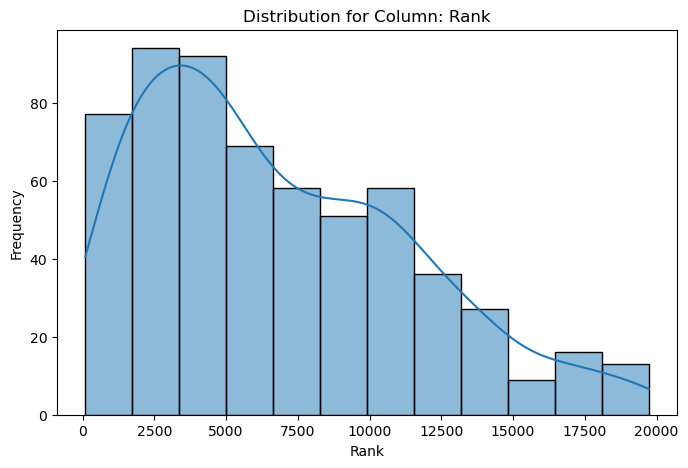

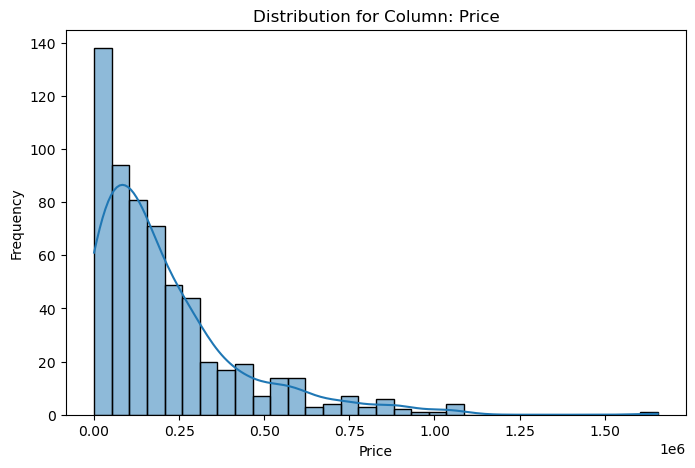

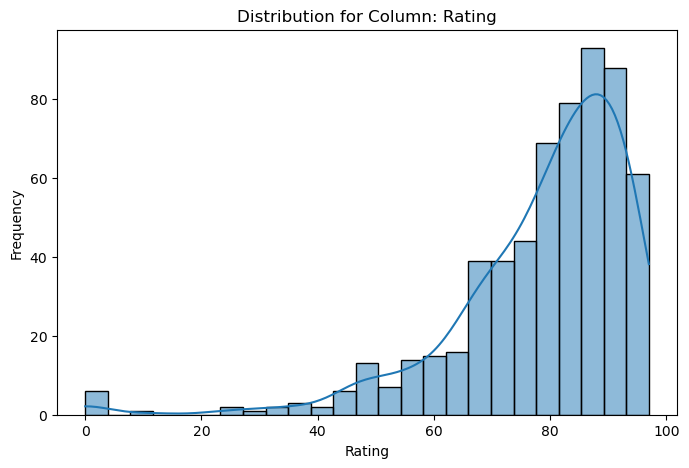

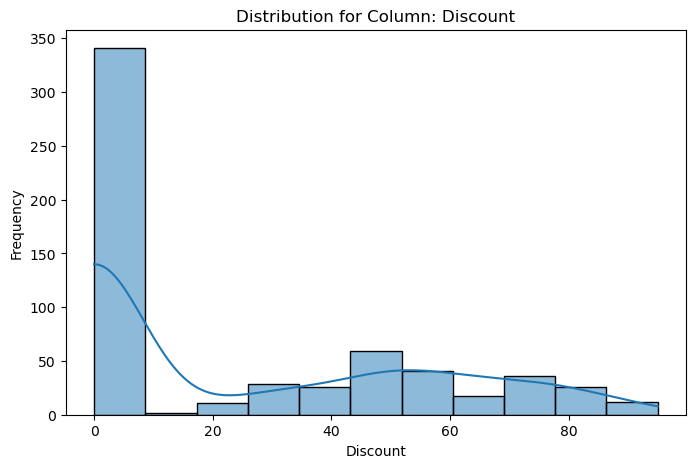

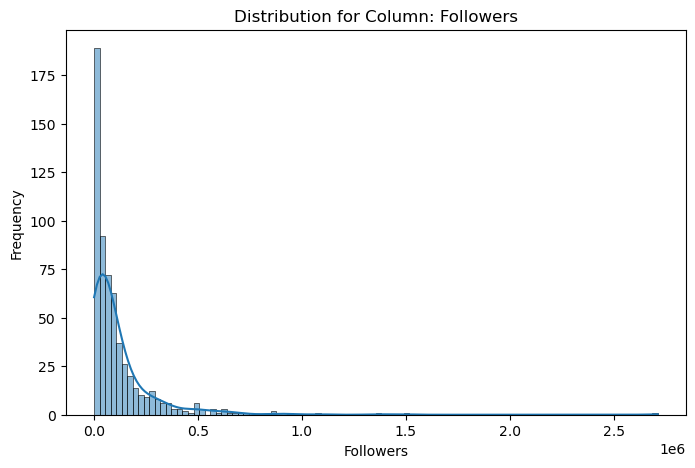

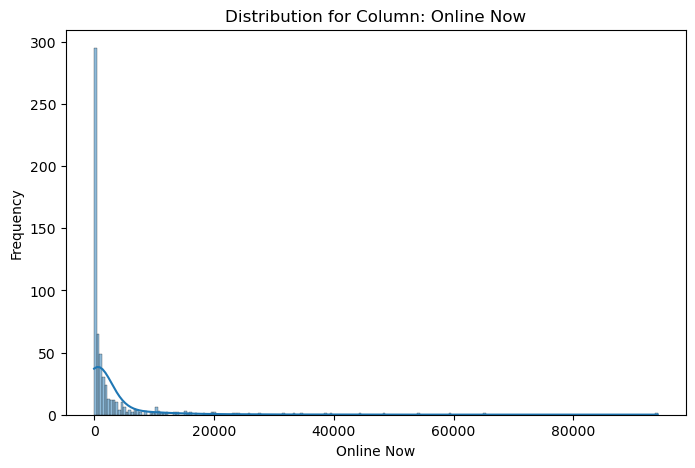

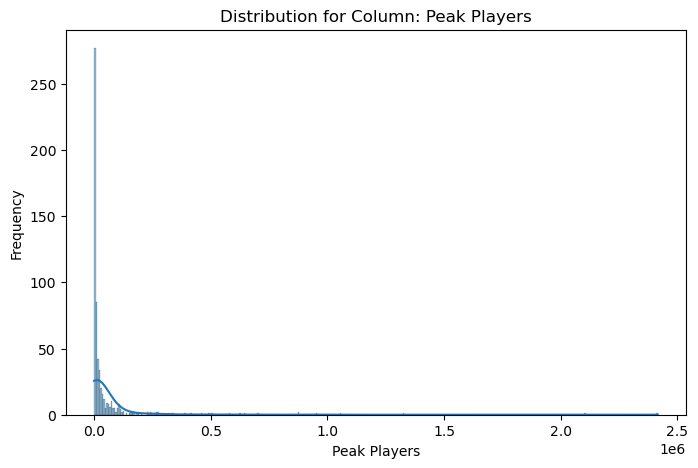

In [15]:
# Define all the columns you want to visualize in a list
columns_for_diplot = ['Rank', 'Price', 'Rating', 'Discount', 'Followers', 'Online Now', 'Peak Players']

# 2. Use a 'for' loop to plot for each column in the list
# This line is now correctly un-indented
print("Creating a distribution plot for each column...")

for column in columns_for_diplot:
    # plt.figure() creates a new figure for each plot so they don't overwrite each other
    plt.figure(figsize=(8, 5))

    # Create a histogram for the 'column' being processed by the loop
    sns.histplot(data=df, x=column, kde=True)

    # Give a dynamic title according to the column name
    plt.title(f'Distribution for Column: {column}')

    # Label the x and y axes to make them more informative
    plt.xlabel(column)
    plt.ylabel('Frequency')

    # Display the plot
    plt.show()

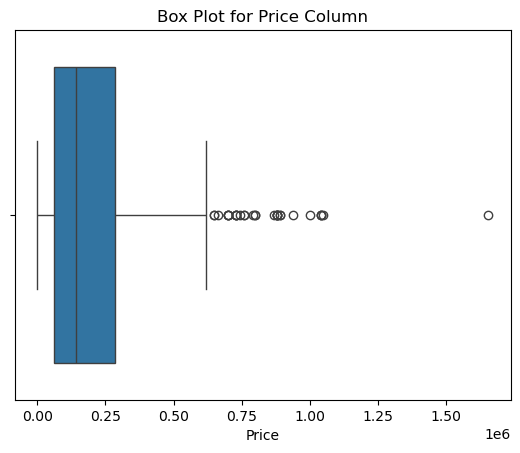

In [16]:
sns.boxplot(data=df, x='Price')
plt.title('Box Plot for Price Column')
plt.show()

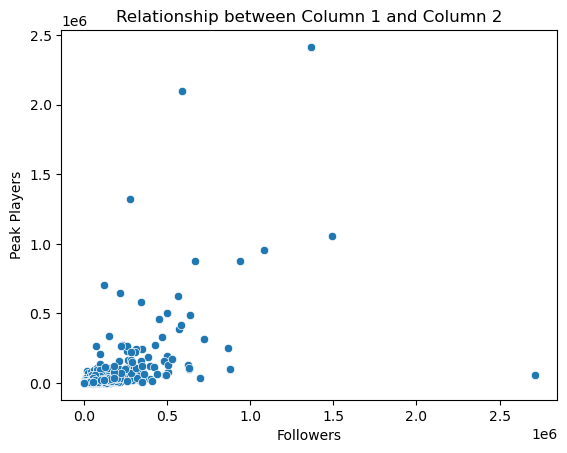

In [17]:
# Numerik vs. Numerik
# Followers vs. Peak Players (Strong Positive Correlation)
sns.scatterplot(x='Followers', y='Peak Players', data=df)
plt.title('Relationship between Column 1 and Column 2')
plt.show()

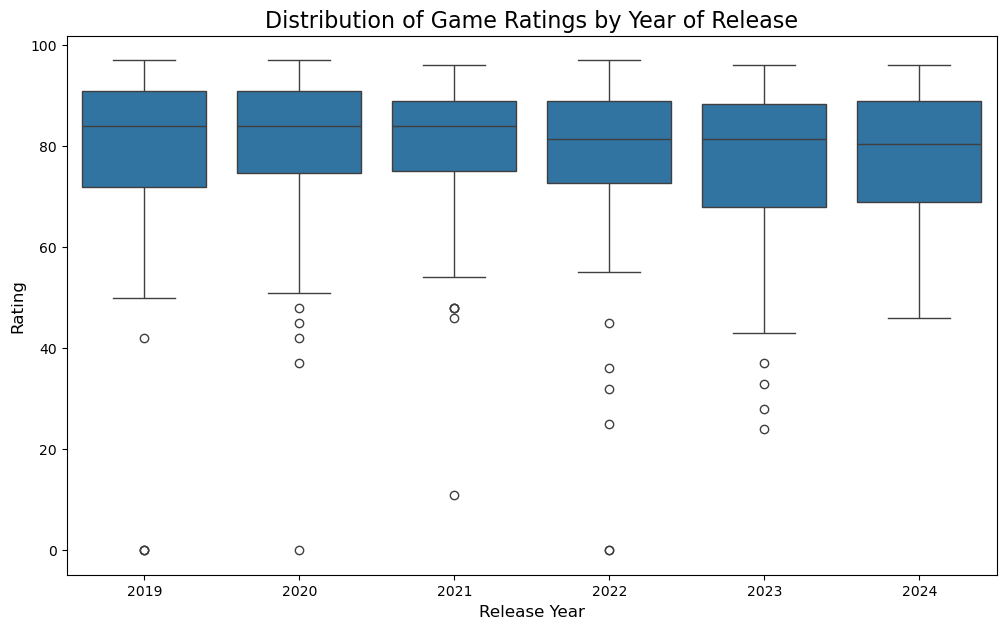

In [18]:
# Kategorikal vs. Numerik
plt.figure(figsize=(12, 7)) # Resize the image to make it clearer

sns.boxplot(x='Release Year', y='Rating', data=df)

plt.title('Distribution of Game Ratings by Year of Release', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

In [19]:
# Kategorikal vs. Kategorikal
# Create a contingency table using pd.crosstab
contingency_table = pd.crosstab(index=df['Release Year'], columns=df['Discount'])

print("===== Contingency Table =====")
print(contingency_table)

===== Contingency Table =====
Discount      0   10  15  20  22  25  27  30  33  34  35  38  40  43  45  47  \
Release Year                                                                   
2019          57   0   0   0   0   0   0   4   0   0   0   0   3   0   0   0   
2020          54   0   0   0   0   0   0   3   0   0   0   0   2   1   0   0   
2021          58   0   0   0   0   0   1   5   2   0   1   0   0   0   1   0   
2022          60   0   0   0   0   0   0   6   0   1   1   0   1   0   0   0   
2023          49   0   1   2   0   1   0   3   0   0   1   0   6   0   1   0   
2024          63   1   0   4   1   3   0   4   0   0   0   1   9   0   1   1   

Discount      50  52  55  59  60  62  65  66  67  70  71  75  77  80  85  86  \
Release Year                                                                   
2019           3   0   0   0   7   1   0   1   1   4   0   8   0   6   1   0   
2020           6   0   1   0  10   0   0   2   2   3   0   6   1   4   1   0   
2021     

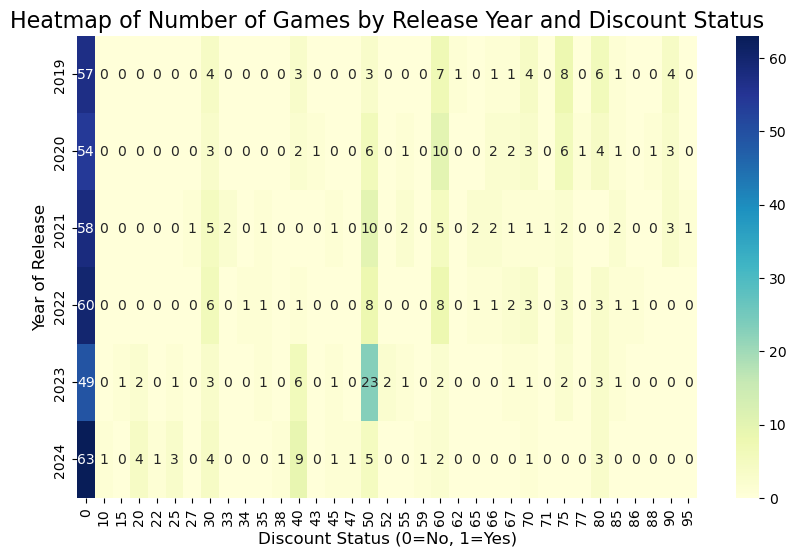

In [20]:
# Visualize the table with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')

# annot=True displays the number inside the box
# fmt=‘d’ ensures numbers are displayed as integers
# cmap selects the color palette

plt.title('Heatmap of Number of Games by Release Year and Discount Status', fontsize=16)
plt.ylabel('Year of Release', fontsize=12)
plt.xlabel('Discount Status (0=No, 1=Yes)', fontsize=12)
plt.show()

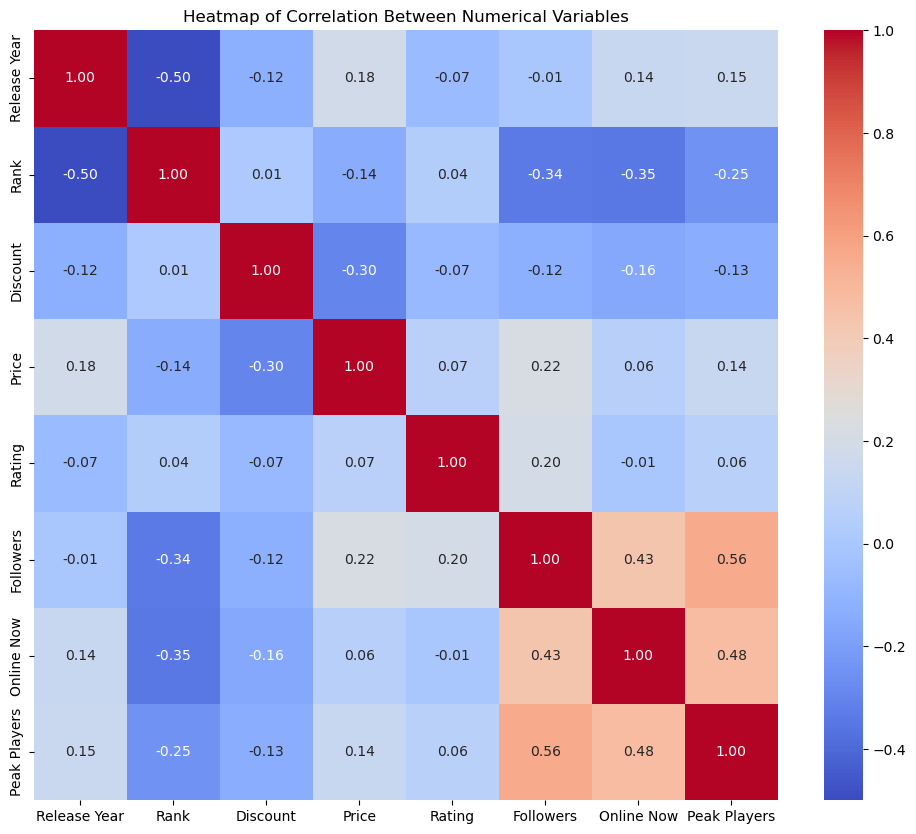

In [21]:
# Calculating the correlation matrix (for numeric columns only)
correlation_matrix = df.corr(numeric_only=True)

# Create a heatmap
plt.figure(figsize=(12, 10)) # Set the image size to be larger
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of Correlation Between Numerical Variables')
plt.show()

# Making ML Model using Linear Regression


In [22]:
df

,Release Year,Rank,Game Name,Discount,Price,Rating,Release Date,Followers,Online Now,Peak Players,Release Merge
0,2019,460,Destiny 2,0,0,79,10/01/2019,719675,23683,316750,01 Oct 2019
1,2019,500,Hunt: Showdown 1896,50,127500,72,08/27/2019,487821,11991,60124,27 Aug 2019
2,2019,780,STAR WARS Jedi: Fallen Order™,75,119750,87,11/15/2019,205752,2262,46550,15 Nov 2019
3,2019,810,Blasphemous,90,19999,88,09/10/2019,90902,2274,3465,10 Sep 2019
4,2019,1210,Oxygen Not Included,70,35999,95,07/30/2019,396429,10600,27486,30 Jul 2019
5,2019,1310,Assetto Corsa Competizione,75,112250,90,05/29/2019,139112,1038,12376,29 May 2019
6,2019,1330,Red Dead Redemption 2,0,879000,91,12/05/2019,875506,23939,99993,05 Dec 2019
7,2019,1480,Trailmakers,75,29999,90,09/18/2019,72105,1472,4898,18 Sep 2019
8,2019,1560,Mortal Kombat 11,0,0,86,04/23/2019,168432,1467,35147,23 Apr 2019
9,2019,1850,Total War: THREE KINGDOMS,75,135249,71,05/23/2019,499140,3781,192298,23 May 2019


In [ ]:
from sklearn.model_selection import train_test_split

fitur = ['Followers', 'Rank', 'Online Now']
target = 'Peak Players'
df_reg = df[fitur + [target]]
X = df_reg[fitur].values
y = df_reg[target].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


In [24]:
def knn_regressor_predict(X_train, y_train, X_test, k=4):
    preds = []
    for x in X_test:
        dists = np.linalg.norm(X_train - x, axis=1)
        idx_knn = np.argsort(dists)[:k]
        pred = np.mean(y_train[idx_knn])
        preds.append(pred)
    return np.array(preds)

In [33]:
y_pred_knn = knn_regressor_predict(X_train, y_train, X_test, k=4)

In [36]:
mse_knn = np.mean((y_test - y_pred_knn) ** 2)
mae_knn = np.mean(np.abs(y_test - y_pred_knn))
r2_knn = 1 - np.sum((y_test - y_pred_knn) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)

print("Manual KNN Regressor Results(k=4):")
print("====================================")
print(f"Mean Squared Error(MSE)  : {mse_knn:.2f}")
print(f"Mean Absolute Error(MAE) : {mae_knn:.2f}")
print(f"R2 Score                 : {r2_knn:.4f}")

Manual KNN Regressor Results(k=4):
Mean Squared Error(MSE)  : 1174238234.66
Mean Absolute Error(MAE) : 17976.60
R2 Score                 : 0.9365


In [27]:
for i in range(10):
    print(f"Fitur: {[X_test[i, j] for j in range(X_test.shape[1])]}, Actual: {y_test[i]}, Predicted: {y_pred_knn[i]:.2f}")

Fitur: [np.int64(63000), np.int64(70), np.int64(81), np.int64(172996), np.int64(2050)], Actual: 11696, Predicted: 40849.50
Fitur: [np.int64(0), np.int64(0), np.int64(24), np.int64(99261), np.int64(1900)], Actual: 75608, Predicted: 27177.50
Fitur: [np.int64(65000), np.int64(0), np.int64(89), np.int64(124679), np.int64(3730)], Actual: 113798, Predicted: 55593.25
Fitur: [np.int64(162999), np.int64(0), np.int64(83), np.int64(0), np.int64(15120)], Actual: 0, Predicted: 0.00
Fitur: [np.int64(51502), np.int64(55), np.int64(96), np.int64(48393), np.int64(14030)], Actual: 772, Predicted: 10169.00
Fitur: [np.int64(96328), np.int64(55), np.int64(84), np.int64(28329), np.int64(12100)], Actual: 1073, Predicted: 1945.75
Fitur: [np.int64(299500), np.int64(0), np.int64(93), np.int64(261984), np.int64(2180)], Actual: 38725, Predicted: 109639.25
Fitur: [np.int64(79679), np.int64(52), np.int64(86), np.int64(30867), np.int64(6670)], Actual: 4152, Predicted: 25645.00
Fitur: [np.int64(113700), np.int64(70),